In [2]:
# CELL 1: Setup, Imports & Data Loading

# --- Core Libraries & Setup ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, average_precision_score, balanced_accuracy_score, matthews_corrcoef, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy.stats import chi2_contingency
from tab_transformer_pytorch import TabTransformer
from pathlib import Path
import copy
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
import random
random.seed(SEED); np.random.seed(SEED)
try:
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

# --- Global Settings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 8)})

# --- Load Data (NEW 80/20 SPLIT) ---
train_df = pd.read_csv('GSE95640_train_80.csv', index_col=0)
test_df = pd.read_csv('GSE95640_test_20.csv', index_col=0)

target_map = {
    'CID1 is for the baseline without LCD': 0,
    'CID2 is after 8 weeks of LCD': 1
}

y_train_full = train_df['time'].map(target_map)
X_train_full = train_df.drop(columns=['time'])

y_test_holdout = test_df['time'].map(target_map)
X_test_holdout = test_df.drop(columns=['time'])

print(f"80% Train ({len(X_train_full)} samples) and 20% Test ({len(X_test_holdout)} samples) loaded successfully.")

80% Train (305 samples) and 20% Test (77 samples) loaded successfully.


In [1]:
# CELL 2: Define All Helper Functions

# This function is heavily simplified to only handle 'age' and 'gender'.
def process_fold_features(X_train, y_train, X_test):
    """
    Encapsulates all feature engineering for a single fold (GSE95640 version).
    """
    
    # --- 1. Process Categorical (Clinical) Features ---
    
    # 1a. Define the known columns
    known_cat_cols = ['age', 'gender', 'tissue']
    cat_cols = [col for col in known_cat_cols if col in X_train.columns]
    
    if not cat_cols:
        print("  No clinical features found.")
        X_train_cat = pd.DataFrame(index=X_train.index)
        X_test_cat = pd.DataFrame(index=X_test.index)
        selected_categorical_features = []
    
    else:
        X_train_cat = X_train[cat_cols].copy()
        X_test_cat = X_test[cat_cols].copy()

        # 1b. Remove 'tissue' as it is constant
        if 'tissue' in X_train_cat.columns:
            X_train_cat.drop(columns=['tissue'], inplace=True)
            X_test_cat.drop(columns=['tissue'], inplace=True)

        # 1c. Clean 'age' (the only numeric col)
        if 'age' in X_train_cat.columns:
            X_train_cat['age'] = pd.to_numeric(X_train_cat['age'], errors='coerce')
            X_test_cat['age'] = pd.to_numeric(X_test_cat['age'], errors='coerce')

        # 1d. Impute missing values (using training fold data)
        imputation_values = {}
        for col in X_train_cat.columns:
            if pd.api.types.is_numeric_dtype(X_train_cat[col]):
                imputation_values[col] = X_train_cat[col].median()
            else:
                # Use mode for 'gender'
                imputation_values[col] = X_train_cat[col].mode()[0]
                
        for col, value in imputation_values.items():
            X_train_cat[col] = X_train_cat[col].fillna(value)
            X_test_cat[col] = X_test_cat[col].fillna(value)

        # 1e. Bin 'age'
        if 'age' in X_train_cat.columns:
            # Use 5 quantiles, drop duplicates if needed
            _, age_bins = pd.qcut(X_train_cat['age'], q=5, retbins=True, duplicates='drop')
            age_labels = [f'a{k + 1}' for k in range(len(age_bins) - 1)]
            
            for df in [X_train_cat, X_test_cat]:
                df['age_category'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, include_lowest=True)
                df.drop(columns=['age'], inplace=True)

        # 1f. Select features using Chi-squared test (only on 'age_category' and 'gender')
        candidate_for_chi2 = [col for col in X_train_cat.columns if col in ['age_category', 'gender']]
        selected_categorical_features = []
        for col in candidate_for_chi2:
            try:
                # Test association between the feature and the target 'y_train'
                crosstab = pd.crosstab(X_train_cat[col].astype('category'), y_train)
                if crosstab.shape[0] > 1 and crosstab.shape[1] > 1:
                    p_value = chi2_contingency(crosstab)[1]
                    if p_value < 0.05:
                        selected_categorical_features.append(col)
            except Exception as e:
                print(f"  Skipping chi2 for {col}: {e}")

        print(f"  Selected {len(selected_categorical_features)} clinical features: {selected_categorical_features}")

    # --- 2. Process Continuous (Gene) Features ---
    
    # 2a. Isolate gene columns
    gene_cols = X_train.columns.drop(cat_cols, errors='ignore')
    X_train_cont_raw = X_train[gene_cols].copy()
    X_test_cont_raw = X_test[gene_cols].copy()

    # 2b. Handle duplicate gene symbols (same as before)
    # Sum counts for duplicate gene symbols
    X_train_cont_raw = X_train_cont_raw.T.groupby(level=0).sum().T
    all_gene_columns = X_train_cont_raw.columns
    # Reindex test set to match training set columns
    X_test_cont_raw = X_test_cont_raw.T.groupby(level=0).sum().T.reindex(columns=all_gene_columns, fill_value=0)

    # 2c. Run DESeq2 on the training fold to find significant genes
    significant_genes = []
    try:
        samples_df = pd.DataFrame({'condition': y_train})
        dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design='~condition')
        dds.deseq2()
        stat_res = DeseqStats(dds, contrast=['condition', 1, 0]) # 1='After 8 weeks', 0='Baseline'
        stat_res.summary()
        results_df = stat_res.results_df
        
        # (Using same thresholds)
        significant_genes = results_df[
            (results_df['padj'] < 0.05) & (abs(results_df['log2FoldChange']) > 1.0)
        ].index.tolist()
    except Exception as e:
        print(f"  DESeq2 analysis failed in this fold: {e}")

    print(f"  Found {len(significant_genes)} significant genes.")

    return X_train_cat, X_test_cat, selected_categorical_features, X_train_cont_raw, X_test_cont_raw, significant_genes


def train_tt_in_cv(X_cat_train, X_cont_train, y_train, X_cat_test, X_cont_test, cat_cardinalities, fold_name=""):
    """
    A robust training function for Tab-Transformer inside a CV loop,
    featuring Early Stopping, Validation Split, and Parameter Counting.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # --- 1. Split 10% Validation Set for Early Stopping ---
    indices = np.arange(len(y_train))
    try:
        train_idx, val_idx = train_test_split(indices, test_size=0.1, stratify=y_train.values, random_state=42)
    except ValueError:
        train_idx, val_idx = train_test_split(indices, test_size=0.1, random_state=42)
        
    y_train_full = y_train.values
    y_tr = torch.tensor(y_train_full[train_idx], dtype=torch.long).to(device)
    y_val = torch.tensor(y_train_full[val_idx], dtype=torch.long).to(device)
    
    # Safely handle potentially empty tensors
    X_cat_tr = X_cat_train[train_idx].to(device) if X_cat_train.shape[1] > 0 else torch.empty(len(train_idx), 0, dtype=torch.long).to(device)
    X_cat_val = X_cat_train[val_idx].to(device) if X_cat_train.shape[1] > 0 else torch.empty(len(val_idx), 0, dtype=torch.long).to(device)
    
    X_cont_tr = X_cont_train[train_idx].to(device) if X_cont_train.shape[1] > 0 else torch.empty(len(train_idx), 0).to(device)
    X_cont_val = X_cont_train[val_idx].to(device) if X_cont_train.shape[1] > 0 else torch.empty(len(val_idx), 0).to(device)

    # --- 2. Model Initialization & Parameter Counting ---
    model = TabTransformer(
        categories=cat_cardinalities,
        num_continuous=X_cont_train.shape[1],
        dim=32, dim_out=2, depth=6, heads=8
    ).to(device)
    
    if fold_name == "Final":
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  [TabTransformer] Trainable Parameters: {num_params}")

    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    
    pos = float((y_train_full[train_idx] == 1).sum())
    neg = float((y_train_full[train_idx] == 0).sum())
    w = torch.tensor([0.5, 0.5], dtype=torch.float32) if pos == 0 or neg == 0 else torch.tensor([neg/(pos+neg), pos/(pos+neg)], dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(weight=w.to(device))
    
    # --- 3. Training Loop with Early Stopping ---
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []

    for epoch in range(100): 
        model.train()
        optimizer.zero_grad()
        output = model(X_cat_tr, X_cont_tr)
        loss = criterion(output, y_tr)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_output = model(X_cat_val, X_cont_val)
            val_loss = criterion(val_output, y_val).item()
            
        train_losses.append(loss.item())
        val_losses.append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            if fold_name == "Final":
                print(f"  [Early Stopping] Triggered at epoch {epoch+1}")
            break
            
    # --- 4. Restore Best Weights & Plot Curve ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    if fold_name == "Final":
        plt.figure(figsize=(8, 6))
        plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2)
        plt.plot(val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2)
        plt.title('TabTransformer Training vs Validation Loss (GSE95640)')
        plt.xlabel('Epochs')
        plt.ylabel('CrossEntropy Loss')
        plt.legend()
        sns.despine()
        curve_path = OUT_DIR / "GSE95640_tabtransformer_loss_curve.png"
        plt.savefig(curve_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"  [Plot] Saved Loss Curve to: {curve_path}")

    # --- 5. Evaluate on actual Hold-out / Test Set ---
    model.eval()
    with torch.no_grad():
        test_output = model(X_cat_test.to(device), X_cont_test.to(device))
        y_pred_proba = torch.softmax(test_output, dim=1).cpu().numpy()[:, 1]
        
    return y_pred_proba

def get_comprehensive_metrics(y_true, y_prob):
    """
    A unified evaluator returning 7 core metrics to satisfy stringent reviewer demands.
    """
    y_pred = (y_prob >= 0.5).astype(int)
    
    # 1. Base Metrics
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    cr = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro_f1 = cr['macro avg']['f1-score']
    
    # 2. Imbalance-Aware Metrics
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    # 3. Sensitivity & Specificity
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        sensitivity, specificity = 0.0, 0.0
        
    return {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Macro F1': macro_f1,
        'Bal. Acc.': bal_acc,
        'MCC': mcc,
        'Sensitivity': sensitivity,
        'Specificity': specificity
    }

def get_bootstrap_ci(y_true, y_prob, metric_func, n_boot=1000, alpha=0.05):
    """
    Bootstrap resampling to estimate 95% CI for a given metric.
    Includes safeguards for extremely small/imbalanced datasets (e.g., GSE240671).
    """
    boot_scores = []
    y_true_arr = np.array(y_true)
    y_prob_arr = np.array(y_prob)
    
    for _ in range(n_boot):
        try:
            idx = resample(np.arange(len(y_true_arr)), stratify=y_true_arr)
            score = metric_func(y_true_arr[idx], y_prob_arr[idx])
            boot_scores.append(score)
        except ValueError:
            continue
            
    if len(boot_scores) == 0:
        return np.nan, np.nan, np.nan
        
    boot_scores = np.array(boot_scores)
    lower = np.percentile(boot_scores, 100 * (alpha / 2))
    upper = np.percentile(boot_scores, 100 * (1 - alpha / 2))
    return np.mean(boot_scores), lower, upper

print("Helper functions defined.")

Helper functions defined.


In [3]:
# CELL 3: The Main Cross-Validation Loop

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Create a dictionary to store results
results = {'AUCs': {}, 'TPRs': {}}
mean_fpr = np.linspace(0, 1, 100)  # Common x-axis for ROC curves
cr_macro = {}
cr_weighted = {}

# --- Start the Loop ---
for i, (train_index, test_index) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n========== FOLD {i + 1}/{N_SPLITS} ========== ")
    X_train, X_test = X_train_full.iloc[train_index], X_train_full.iloc[test_index]
    y_train, y_test = y_train_full.iloc[train_index], y_train_full.iloc[test_index]

    # --- 1. Perform feature engineering for the current fold ---
    X_train_cat, X_test_cat, sel_cat_feats, X_train_cont_raw, X_test_cont_raw, sig_genes = process_fold_features(
        X_train, y_train, X_test)

    # --- 2. Prepare final data subsets for this fold ---
    
    # Check if we have features of each type
    has_cont = (len(sig_genes) > 0)
    has_cat = (len(sel_cat_feats) > 0)
    
    # Scikit-learn data
    scaler = StandardScaler()
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
    
    # Prep continuous data (if it exists)
    if has_cont:
        # Use log1p (same as original script)
        X_train_cont_final = pd.DataFrame(scaler.fit_transform(np.log1p(X_train_cont_raw[sig_genes])), index=X_train.index, columns=sig_genes)
        X_test_cont_final = pd.DataFrame(scaler.transform(np.log1p(X_test_cont_raw[sig_genes])), index=X_test.index, columns=sig_genes)
    else:
        # Create empty dataframes
        X_train_cont_final = pd.DataFrame(index=X_train.index)
        X_test_cont_final = pd.DataFrame(index=X_test.index)

    # Prep categorical data (if it exists)
    if has_cat:
        X_train_cat_final = pd.DataFrame(onehot.fit_transform(X_train_cat[sel_cat_feats]), index=X_train.index, columns=onehot.get_feature_names_out())
        X_test_cat_final = pd.DataFrame(onehot.transform(X_test_cat[sel_cat_feats]), index=X_test.index, columns=onehot.get_feature_names_out())
    else:
        X_train_cat_final = pd.DataFrame(index=X_train.index)
        X_test_cat_final = pd.DataFrame(index=X_test.index)
        
    X_train_comb = pd.concat([X_train_cat_final, X_train_cont_final], axis=1)
    X_test_comb = pd.concat([X_test_cat_final, X_test_cont_final], axis=1)

    # Tab-Transformer data
    if has_cat:
        ordinal = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1);
        ordinal.fit(X_train_cat[sel_cat_feats])
        X_train_cat_ord = torch.tensor(ordinal.transform(X_train_cat[sel_cat_feats]), dtype=torch.long)
        X_test_cat_ord = torch.tensor(ordinal.transform(X_test_cat[sel_cat_feats]), dtype=torch.long)
        cat_cards = [len(cats) for cats in ordinal.categories_]
    else:
        X_train_cat_ord = torch.empty(len(X_train), 0, dtype=torch.long)
        X_test_cat_ord = torch.empty(len(X_test), 0, dtype=torch.long)
        cat_cards = []

    if has_cont:
        X_train_cont_tensor = torch.tensor(X_train_cont_final.values, dtype=torch.float32)
        X_test_cont_tensor = torch.tensor(X_test_cont_final.values, dtype=torch.float32)
    else:
        X_train_cont_tensor = torch.empty(len(X_train), 0)
        X_test_cont_tensor = torch.empty(len(X_test), 0)


    # --- 3. Run all experiments for this fold ---
    models_to_run = {}
    
    if has_cont:
        models_to_run['TT_cont'] = lambda: train_tt_in_cv(
            torch.empty(len(X_train), 0, dtype=torch.long), X_train_cont_tensor, y_train,
            torch.empty(len(X_test), 0, dtype=torch.long), X_test_cont_tensor, [])
        models_to_run['RF_cont'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LR_cont'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LASSO_cont'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] XGBoost (gene only)
        models_to_run['XGB_cont'] = lambda: XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42, 
            scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum() if y_train.sum() > 0 else 1
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] LightGBM (gene only)
        models_to_run['LGBM_cont'] = lambda: LGBMClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

        # [NEW] CatBoost (gene only)
        models_to_run['CB_cont'] = lambda: CatBoostClassifier(
            iterations=100, depth=4, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] MLP (gene only)
        models_to_run['MLP_cont'] = lambda: MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

    if has_cat:
        models_to_run['TT_cat'] = lambda: train_tt_in_cv(
            X_train_cat_ord, torch.empty(len(X_train), 0), y_train, X_test_cat_ord, torch.empty(len(X_test), 0),
            cat_cards)

    # Only run combined models if *both* feature types exist
    if has_cat and has_cont:
        models_to_run['TT_comb'] = lambda: train_tt_in_cv(
            X_train_cat_ord, X_train_cont_tensor, y_train,
            X_test_cat_ord, X_test_cont_tensor, cat_cards
        )
        models_to_run['RF_comb'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LR_comb'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LASSO_comb'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] XGBoost
        models_to_run['XGB_comb'] = lambda: XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42, 
            scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum() if y_train.sum() > 0 else 1
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] LightGBM
        models_to_run['LGBM_comb'] = lambda: LGBMClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]

        # [NEW] CatBoost (combined)
        models_to_run['CB_comb'] = lambda: CatBoostClassifier(
            iterations=100, depth=4, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] MLP (combined)
        models_to_run['MLP_comb'] = lambda: MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]

    
    if not models_to_run:
        print(f"  Fold {i+1} skipped: No 'cat' or 'cont' features were found.")
        continue

    # Evaluate all models defined for this fold
    for name, train_eval_func in models_to_run.items():
        if name not in results['AUCs']:  # Initialize lists on first fold
            results['AUCs'][name] = []
            results['TPRs'][name] = []
            cr_macro[name] = []
            cr_weighted[name] = []

        y_proba = train_eval_func()
        auc_score = roc_auc_score(y_test, y_proba)
        results['AUCs'][name].append(auc_score)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        results['TPRs'][name].append(interp_tpr)
        print(f"  {name}: AUC = {auc_score:.4f}")
        
        y_pred = (y_proba >= 0.5).astype(int)
        cr = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        cr_macro[name].append([
            cr["macro avg"]["precision"],
            cr["macro avg"]["recall"],
            cr["macro avg"]["f1-score"],
        ])
        cr_weighted[name].append([
            cr["weighted avg"]["precision"],
            cr["weighted avg"]["recall"],
            cr["weighted avg"]["f1-score"],
        ])

print("\n========== CROSS-VALIDATION COMPLETE ==========")


========== FOLD 1/5 ========== 
  Selected 0 clinical features: []


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.23 seconds.

Fitting dispersions...
... done in 1.40 seconds.

Fitting dispersion trend curve...
... done in 0.45 seconds.

Fitting MAP dispersions...
... done in 1.81 seconds.

Fitting LFCs...
... done in 1.59 seconds.

Calculating cook's distance...
... done in 0.29 seconds.

Replacing 371 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.10 seconds.

Fitting LFCs...
... done in 0.10 seconds.

Running Wald tests...
... done in 1.47 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         14.909157        0.191178  0.089596  2.133788  0.032860  0.097999
A1BG-AS1     24.872687        0.161303  0.069304  2.327472  0.019940  0.066529
A1CF          1.287809       -0.018442  0.197777 -0.093245  0.925709  0.962444
A2M       27558.651388       -0.150769  0.044905 -3.357506  0.000786  0.004819
A2M-AS1     994.205155       -0.201259  0.049264 -4.085346  0.000044  0.000417
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.370594        0.255296  0.158626  1.609421  0.107524  0.238177
ZYG11B     1619.242299       -0.125968  0.033711 -3.736735  0.000186  0.001429
ZYX        1324.165367        0.230394  0.077200  2.984384  0.002842  0.014149
ZZEF1      1617.727165        0.005355  0.057529  0.093091  0.925831  0.962532
ZZZ3        995.638608        0.034601  0.023944  1.445111  0.148427  0.2997

...

Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         14.961894        0.192578  0.093786  2.053379  0.040036  0.119796
A1BG-AS1     24.738859        0.104031  0.072849  1.428042  0.153280  0.318153
A1CF          1.307606       -0.292729  0.194222 -1.507189  0.131762  0.287659
A2M       26885.323709       -0.074243  0.045219 -1.641853  0.100620  0.237431
A2M-AS1     969.104440       -0.178338  0.047417 -3.761027  0.000169  0.001475
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.399730        0.228172  0.163023  1.399632  0.161623  0.330700
ZYG11B     1577.481227       -0.118428  0.035512 -3.334831  0.000854  0.005667
ZYX        1314.393564        0.196480  0.079415  2.474104  0.013357  0.051739
ZZEF1      1557.993270        0.045042  0.057300  0.786075  0.431824  0.630204
ZZZ3        978.216736        0.013613  0.023347  0.583050  0.559859  0.7353

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.23 seconds.

Fitting dispersions...
... done in 1.68 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 1.84 seconds.

Fitting LFCs...
... done in 2.04 seconds.

Calculating cook's distance...
... done in 0.32 seconds.

Replacing 359 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.10 seconds.

Fitting LFCs...
... done in 0.10 seconds.

Running Wald tests...
... done in 1.45 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         14.597194        0.185000  0.086873  2.129554  0.033208  0.105946
A1BG-AS1     23.991674        0.190301  0.069261  2.747609  0.006003  0.028036
A1CF          1.331712       -0.246012  0.194260 -1.266407  0.205367  0.393753
A2M       26579.293563       -0.079090  0.046508 -1.700579  0.089022  0.218380
A2M-AS1     974.949126       -0.165071  0.047658 -3.463624  0.000533  0.003905
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.500502        0.021966  0.167813  0.130894  0.895859  0.949016
ZYG11B     1563.240924       -0.117815  0.034391 -3.425712  0.000613  0.004397
ZYX        1281.411891        0.241491  0.075380  3.203639  0.001357  0.008443
ZZEF1      1524.135569        0.071272  0.057933  1.230257  0.218601  0.410712
ZZZ3        970.003415        0.009586  0.024319  0.394153  0.693468  0.8300

In [4]:
# CELL 4: Results Summary & Tables

def _cr_store_to_df(store: dict, label: str) -> pd.DataFrame:
    rows = []
    for name, arr in store.items():
        A = np.asarray(arr, dtype=float)  # shape (n_folds, 3)
        mu = A.mean(axis=0)
        sd = A.std(axis=0)
        rows.append([
            name.replace("_", " ").title(), # Prettify name
            mu[0], sd[0],
            mu[1], sd[1],
            mu[2], sd[2],
        ])
    return pd.DataFrame(rows, columns=[
        "Model",
        f"{label} Precision (mean)", f"{label} Precision (std)",
        f"{label} Recall (mean)",    f"{label} Recall (std)",
        f"{label} F1 (mean)",        f"{label} F1 (std)",
    ]).sort_values("Model").reset_index(drop=True)


# --- AUC Summary Table ---
summary_data = []
for name, auc_list in results['AUCs'].items():
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    summary_data.append({
        'Experiment': name.replace("_", " ").title(),
        'Mean AUC': mean_auc,
        'Std Dev (±)': std_auc
    })

summary_cv_df = pd.DataFrame(summary_data).set_index('Experiment').sort_values(by='Mean AUC', ascending=False)

print("\n--- Final Cross-Validation Performance Summary (GSE95640) ---")
print("Metrics are reported as Mean ± Standard Deviation over 5 folds.")

# Display the styled table (requires a Jupyter environment)
try:
    display(summary_cv_df.style
            .format({'Mean AUC': '{:.3f}', 'Std Dev (±)': '{:.3f}'})
            .background_gradient(cmap='Greens', subset=['Mean AUC'])
            .bar(subset=['Std Dev (±)'], color='#d4edda', align='zero')
            .set_properties(**{'border': '1px solid #dee2e6', 'padding': '8px'})
            .set_table_styles(
        [{'selector': 'thead th', 'props': [('background-color', '#f8f9fa'), ('border-bottom', '2px solid #dee2e6')]}])
            )
except:
    print(summary_cv_df)

# 1. Update output filenames
summary_cv_path = OUT_DIR / "GSE95640_cv_auc_summary.csv"
summary_cv_df.to_csv(summary_cv_path, index=True)
print(f"Saved CV AUC summary to: {summary_cv_path}")


# --- Classification Report Tables ---
macro_df = _cr_store_to_df(cr_macro, "Macro")
weighted_df = _cr_store_to_df(cr_weighted, "Weighted")

print("\n--- Classification Report (Macro avg) — 5-fold mean ± std ---")
try:
    display(macro_df)
except:
    print(macro_df)
    
print("\n--- Classification Report (Weighted avg) — 5-fold mean ± std ---")
try:
    display(weighted_df)
except:
    print(weighted_df)

# 2. Update output filenames
macro_path = OUT_DIR / "GSE95640_cv_classification_report_macro.csv"
weighted_path = OUT_DIR / "GSE95640_cv_classification_report_weighted.csv"
macro_df.to_csv(macro_path, index=False)
weighted_df.to_csv(weighted_path, index=False)
print(f"Saved CR tables to:\n- {macro_path}\n- {weighted_path}")


--- Final Cross-Validation Performance Summary (GSE95640) ---
Metrics are reported as Mean ± Standard Deviation over 5 folds.


,Mean AUC,Std Dev (±)
Experiment,,
Cb Cont,0.945,0.013
Lgbm Cont,0.944,0.022
Tt Cont,0.943,0.010
Lr Cont,0.937,0.003
Lasso Cont,0.937,0.013
Xgb Cont,0.935,0.025
Rf Cont,0.932,0.024
Mlp Cont,0.896,0.053


Saved CV AUC summary to: output\GSE95640_cv_auc_summary.csv

--- Classification Report (Macro avg) — 5-fold mean ± std ---


,Model,Macro Precision (mean),Macro Precision (std),Macro Recall (mean),Macro Recall (std),Macro F1 (mean),Macro F1 (std)
0,Cb Cont,0.873752,0.027285,0.872258,0.028602,0.871938,0.028478
1,Lasso Cont,0.870072,0.027519,0.865269,0.028535,0.865010,0.028484
2,Lgbm Cont,0.871913,0.035894,0.868817,0.038102,0.868424,0.037885
3,Lr Cont,0.875157,0.014056,0.871828,0.019770,0.871662,0.019930
4,Mlp Cont,0.812313,0.071330,0.810323,0.072204,0.809415,0.072758
5,Rf Cont,0.874105,0.049709,0.872043,0.052796,0.871701,0.052936
6,Tt Cont,0.878787,0.024449,0.875161,0.024753,0.875028,0.024668
7,Xgb Cont,0.859451,0.034004,0.859140,0.033943,0.858965,0.033793



--- Classification Report (Weighted avg) — 5-fold mean ± std ---


,Model,Weighted Precision (mean),Weighted Precision (std),Weighted Recall (mean),Weighted Recall (std),Weighted F1 (mean),Weighted F1 (std)
0,Cb Cont,0.873928,0.027549,0.872131,0.028204,0.871963,0.028406
1,Lasso Cont,0.869913,0.027592,0.865574,0.028204,0.865092,0.028433
2,Lgbm Cont,0.871998,0.036377,0.868852,0.037383,0.868486,0.037763
3,Lr Cont,0.875006,0.014484,0.872131,0.019118,0.871744,0.019819
4,Mlp Cont,0.812687,0.071396,0.809836,0.072280,0.809357,0.072829
5,Rf Cont,0.874150,0.050027,0.872131,0.052254,0.871770,0.052822
6,Tt Cont,0.878658,0.024474,0.875410,0.024535,0.875094,0.024637
7,Xgb Cont,0.859617,0.034138,0.859016,0.033756,0.858986,0.033765


Saved CR tables to:
- output\GSE95640_cv_classification_report_macro.csv
- output\GSE95640_cv_classification_report_weighted.csv



--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (GSE95640) ---
Saved figure to: output\GSE95640_cv_roc_only_continuous.png


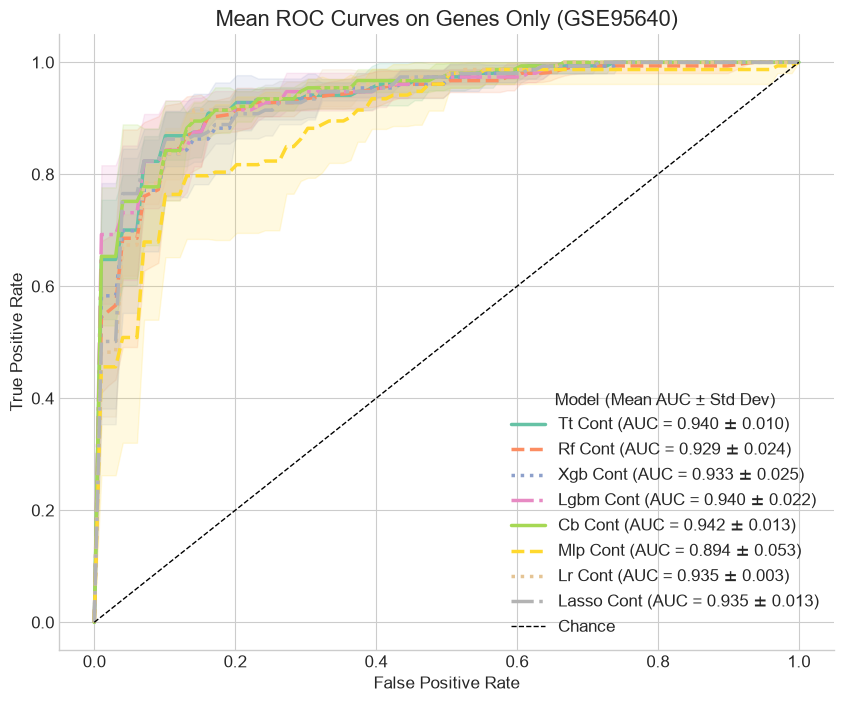


--- Generating Plot 2: Tab-Transformer Ablation Study (GSE95640) ---
Saved figure to: output\GSE95640_cv_roc_tt_internal.png


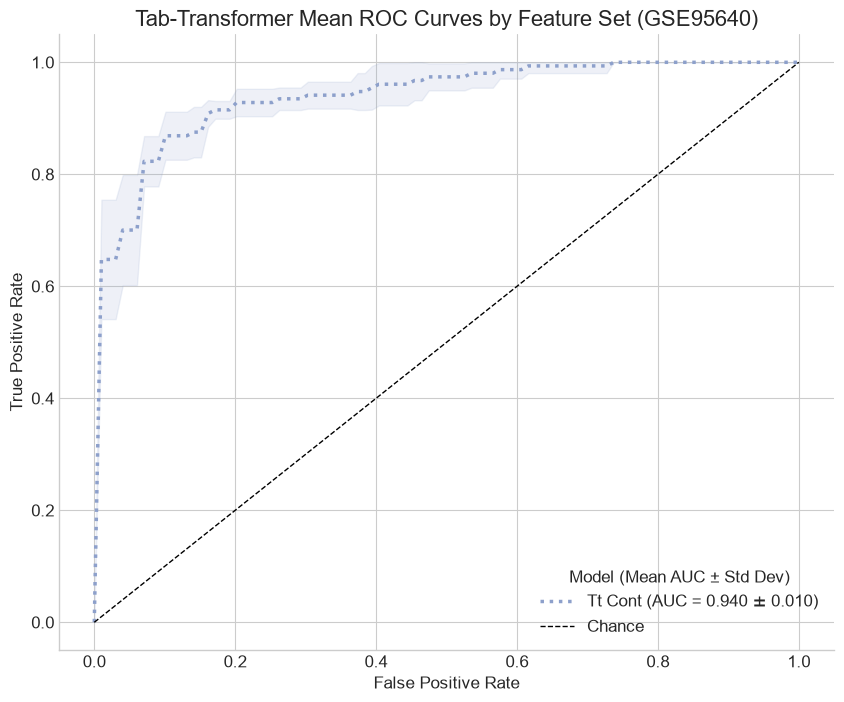


--- Generating Plot 3: Final Model Showdown on Combined Features (GSE95640) ---
No models to plot for 'Mean ROC Curves on Combined Features (GSE95640)'. Skipping figure.


In [5]:
# CELL 5: Generate Final Comparative Plots
def plot_mean_roc_curves_with_std(results_tprs, results_aucs, model_keys, title, save_path=None):
    """
    Helper function to plot multiple mean ROC curves from CV results,
    including a shaded standard deviation band for each curve.
    """
    plt.figure(figsize=(10, 8))
    colors = sns.color_palette('Set2', n_colors=len(model_keys))
    linestyles = ['-', '--', ':', '-.']
    
    # Track which keys actually have results
    plotted_keys = []

    # --- Loop through each model to plot ---
    for i, key in enumerate(model_keys):
        if key not in results_tprs or not results_tprs[key]:
            print(f"Warning: No results found for '{key}'. Skipping this curve.")
            continue
        
        plotted_keys.append(key)
        
        # --- Calculations for the current model ---
        tpr_array = np.array(results_tprs[key])
        mean_tprs = tpr_array.mean(axis=0)
        mean_tprs[-1] = 1.0  # Ensure the curve goes to the top-right corner

        mean_auc = auc(mean_fpr, mean_tprs)
        std_auc = np.std(results_aucs[key])

        std_tpr = tpr_array.std(axis=0)
        tprs_upper = np.minimum(mean_tprs + std_tpr, 1)
        tprs_lower = np.maximum(mean_tprs - std_tpr, 0)

        # --- Plotting for the current model ---
        label_text = f'{key.replace("_", " ").title()} (AUC = {mean_auc:.3f} $\\pm$ {std_auc:.3f})'
        plt.plot(mean_fpr, mean_tprs, color=colors[i], linestyle=linestyles[i % len(linestyles)], lw=2.5,
                 label=label_text)
        plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.15)
    
    # --- Finalize the plot ---
    if not plotted_keys:
        print(f"No models to plot for '{title}'. Skipping figure.")
        plt.close() # Close the empty figure
        return

    plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Chance')
    plt.title(title, fontsize=16)
    plt.xlabel('False Positive Rate');
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", title="Model (Mean AUC ± Std Dev)");
    plt.grid(True);
    sns.despine()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    plt.show()


# 1. Update plot titles and save paths

# --- Plot 1: Continuous Features Only ---
print("\n--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (GSE95640) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_cont', 'RF_cont','XGB_cont', 'LGBM_cont','CB_cont', 'MLP_cont', 'LR_cont', 'LASSO_cont'],
    "Mean ROC Curves on Genes Only (GSE95640)",
    save_path=OUT_DIR / "GSE95640_cv_roc_only_continuous.png"
)

# --- Plot 2: Tab-Transformer Ablation Study ---
print("\n--- Generating Plot 2: Tab-Transformer Ablation Study (GSE95640) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_comb', 'TT_cat', 'TT_cont'],
    "Tab-Transformer Mean ROC Curves by Feature Set (GSE95640)",
    save_path=OUT_DIR / "GSE95640_cv_roc_tt_internal.png"
)

# --- Plot 3: Combined Features Showdown ---
print("\n--- Generating Plot 3: Final Model Showdown on Combined Features (GSE95640) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_comb', 'RF_comb', 'XGB_comb', 'LGBM_comb','CB_comb', 'MLP_comb', 'LR_comb', 'LASSO_comb'],
    "Mean ROC Curves on Combined Features (GSE95640)",
    save_path=OUT_DIR / "GSE95640_cv_roc_combined.png"
)

In [8]:
# ==============================================================================
# [Addition] Final Evaluation: Process features on 80% of the full training set and validate on the remaining 20% of the test set
# ==============================================================================
print("\n========== FINAL EVALUATION ON 20% HOLD-OUT TEST SET (GSE95640) ==========")

print("Processing final features on 80% Train -> applying to 20% Test...")
X_train_cat_full, X_test_cat_full, sel_cat_feats_full, X_train_cont_raw_full, X_test_cont_raw_full, sig_genes_full = process_fold_features(
    X_train_full, y_train_full, X_test_holdout
)

# --- Feature Transformation and Merging ---
has_cont_full = len(sig_genes_full) > 0
has_cat_full = len(sel_cat_feats_full) > 0

scaler_full = StandardScaler()
onehot_full = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

if has_cont_full:
    X_train_cont_final_full = pd.DataFrame(scaler_full.fit_transform(np.log1p(X_train_cont_raw_full[sig_genes_full])), index=X_train_full.index, columns=sig_genes_full)
    X_test_cont_final_full = pd.DataFrame(scaler_full.transform(np.log1p(X_test_cont_raw_full[sig_genes_full])), index=X_test_holdout.index, columns=sig_genes_full)
    X_train_cont_tensor_full = torch.tensor(X_train_cont_final_full.values, dtype=torch.float32)
    X_test_cont_tensor_full = torch.tensor(X_test_cont_final_full.values, dtype=torch.float32)
else:
    X_train_cont_final_full = pd.DataFrame(index=X_train_full.index)
    X_test_cont_final_full = pd.DataFrame(index=X_test_holdout.index)
    X_train_cont_tensor_full = torch.empty(len(X_train_full), 0)
    X_test_cont_tensor_full = torch.empty(len(X_test_holdout), 0)

if has_cat_full:
    X_train_cat_final_full = pd.DataFrame(onehot_full.fit_transform(X_train_cat_full[sel_cat_feats_full]), index=X_train_full.index, columns=onehot_full.get_feature_names_out())
    X_test_cat_final_full = pd.DataFrame(onehot_full.transform(X_test_cat_full[sel_cat_feats_full]), index=X_test_holdout.index, columns=onehot_full.get_feature_names_out())
    
    ordinal_full = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    ordinal_full.fit(X_train_cat_full[sel_cat_feats_full])
    X_train_cat_ord_full = torch.tensor(ordinal_full.transform(X_train_cat_full[sel_cat_feats_full]), dtype=torch.long)
    X_test_cat_ord_full = torch.tensor(ordinal_full.transform(X_test_cat_full[sel_cat_feats_full]), dtype=torch.long)
    cat_cards_full = [len(cats) for cats in ordinal_full.categories_]
else:
    X_train_cat_final_full = pd.DataFrame(index=X_train_full.index)
    X_test_cat_final_full = pd.DataFrame(index=X_test_holdout.index)
    X_train_cat_ord_full = torch.empty(len(X_train_full), 0, dtype=torch.long)
    X_test_cat_ord_full = torch.empty(len(X_test_holdout), 0, dtype=torch.long)
    cat_cards_full = []

# --- Final Evaluation ---
if has_cont_full:
    print("\n--- Running Final Evaluation (7 Metrics + 95% CIs) ---")
    final_results = []
    
    if has_cat_full:
        print("Training and evaluating final models on COMBINED features...")
        X_train_eval = pd.concat([X_train_cat_final_full, X_train_cont_final_full], axis=1)
        X_test_eval = pd.concat([X_test_cat_final_full, X_test_cont_final_full], axis=1)
        model_suffix = "(Comb)"
    else:
        print("Training and evaluating final models on CONTINUOUS features only (no clinical features passed selection)...")
        X_train_eval = X_train_cont_final_full
        X_test_eval = X_test_cont_final_full
        model_suffix = "(Cont)"

    final_models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"),
        'XGBoost': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42, scale_pos_weight=(len(y_train_full)-y_train_full.sum())/y_train_full.sum() if y_train_full.sum() > 0 else 1),
        'LightGBM': LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1),
        'CatBoost': CatBoostClassifier(iterations=100, depth=4, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False),
        'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True)
    }

    if 'X_train_comb_full' in locals() and 'X_test_comb_full' in locals():
        print("  -> [Status] Clinical features survived. Using Combined Data.")
        X_train_base = X_train_comb_full
        X_test_base = X_test_comb_full
        tt_model_name = 'TabTransformer (Comb)'
    else:
        print("  -> [Notice] No Clinical Features survived. Downgrading to Genes Only.")
        X_train_base = X_train_cont_tensor_full.numpy() if hasattr(X_train_cont_tensor_full, 'numpy') else X_train_cont_tensor_full
        X_test_base = X_test_cont_tensor_full.numpy() if hasattr(X_test_cont_tensor_full, 'numpy') else X_test_cont_tensor_full
        tt_model_name = 'TabTransformer (Genes Only)'
        
    # (a) Run the standard machine learning models
    for name, clf in final_models.items():
        clf.fit(X_train_base, y_train_full)
        y_prob = clf.predict_proba(X_test_base)[:, 1]
        
        metrics_dict = get_comprehensive_metrics(y_test_holdout, y_prob)
        mean_auc, low_auc, high_auc = get_bootstrap_ci(y_test_holdout, y_prob, roc_auc_score)
        mean_pr, low_pr, high_pr = get_bootstrap_ci(y_test_holdout, y_prob, average_precision_score)
        
        metrics_dict['ROC-AUC'] = mean_auc
        metrics_dict['PR-AUC'] = mean_pr
        metrics_dict['ROC-AUC (95% CI)'] = f"[{low_auc:.3f} - {high_auc:.3f}]"
        metrics_dict['PR-AUC (95% CI)'] = f"[{low_pr:.3f} - {high_pr:.3f}]"
        metrics_dict['Model'] = name
        
        final_results.append(metrics_dict)

    # (b) Run TabTransformer
    tt_prob_full = train_tt_in_cv(
        X_train_cat_ord_full, X_train_cont_tensor_full, y_train_full, 
        X_test_cat_ord_full, X_test_cont_tensor_full, cat_cards_full, fold_name="Final"
    )

    tt_metrics_dict = get_comprehensive_metrics(y_test_holdout, tt_prob_full)
    tt_mean_auc, tt_low_auc, tt_high_auc = get_bootstrap_ci(y_test_holdout, tt_prob_full, roc_auc_score)
    tt_mean_pr, tt_low_pr, tt_high_pr = get_bootstrap_ci(y_test_holdout, tt_prob_full, average_precision_score)

    tt_metrics_dict['ROC-AUC'] = tt_mean_auc
    tt_metrics_dict['PR-AUC'] = tt_mean_pr
    tt_metrics_dict['ROC-AUC (95% CI)'] = f"[{tt_low_auc:.3f} - {tt_high_auc:.3f}]"
    tt_metrics_dict['PR-AUC (95% CI)'] = f"[{tt_low_pr:.3f} - {tt_high_pr:.3f}]"
    tt_metrics_dict['Model'] = tt_model_name

    final_results.append(tt_metrics_dict)

    # (c) Generate and Display Final Table
    cols_order = ['Model', 'ROC-AUC', 'ROC-AUC (95% CI)', 'PR-AUC', 'PR-AUC (95% CI)', 
                  'Macro F1', 'Bal. Acc.', 'MCC', 'Sensitivity', 'Specificity']

    final_df = pd.DataFrame(final_results)[cols_order].set_index('Model')

    print("\n--- FINAL HOLD-OUT PERFORMANCE (EXPANDED METRICS + CIs) ---")

    format_dict = {col: '{:.3f}' for col in final_df.columns if 'CI' not in col}

    try:
        display(final_df.style
                .format(format_dict)
                .background_gradient(cmap='Blues', subset=['ROC-AUC', 'PR-AUC'])
                .background_gradient(cmap='Greens', subset=['Sensitivity', 'Specificity'])
        )
    except:
        print(final_df)
    final_df.to_csv(OUT_DIR / "GSE95640_final_holdout_performance_with_CIs.csv")
    print(f"Saved final results to: {OUT_DIR / 'GSE95640_final_holdout_performance.csv'}")
else:
    print("Skipping final evaluation: No continuous/gene features present after feature selection.")


========== FINAL EVALUATION ON 20% HOLD-OUT TEST SET (GSE95640) ==========
Processing final features on 80% Train -> applying to 20% Test...
  Selected 0 clinical features: []


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.30 seconds.

Fitting dispersions...
... done in 1.66 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 1.96 seconds.

Fitting LFCs...
... done in 2.14 seconds.

Calculating cook's distance...
... done in 0.38 seconds.

Replacing 350 outlier genes.

Fitting dispersions...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.11 seconds.

Fitting LFCs...
... done in 0.11 seconds.

Running Wald tests...
... done in 1.45 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         14.792520        0.167286  0.080762  2.071344  0.038327  0.105042
A1BG-AS1     24.671650        0.129466  0.062992  2.055267  0.039853  0.108277
A1CF          1.322189       -0.151119  0.172925 -0.873900  0.382173  0.563355
A2M       26919.487389       -0.103616  0.040411 -2.564050  0.010346  0.037161
A2M-AS1     977.710042       -0.189493  0.043629 -4.343269  0.000014  0.000141
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.435369        0.131233  0.146388  0.896473  0.370000  0.551406
ZYG11B     1584.407777       -0.128380  0.030651 -4.188487  0.000028  0.000256
ZYX        1292.036852        0.209374  0.069256  3.023200  0.002501  0.011664
ZZEF1      1559.268935        0.038466  0.051029  0.753801  0.450969  0.627640
ZZZ3        978.092296        0.024317  0.021277  1.142882  0.253088  0.4244

,ROC-AUC,ROC-AUC (95% CI),PR-AUC,PR-AUC (95% CI),Macro F1,Bal. Acc.,MCC,Sensitivity,Specificity
Model,,,,,,,,,
Random Forest,0.884,[0.799 - 0.954],0.908,[0.846 - 0.959],0.789,0.791,0.596,0.684,0.897
XGBoost,0.874,[0.789 - 0.949],0.894,[0.818 - 0.953],0.828,0.830,0.680,0.711,0.949
LightGBM,0.891,[0.810 - 0.957],0.909,[0.845 - 0.964],0.790,0.791,0.591,0.711,0.872
CatBoost,0.894,[0.811 - 0.957],0.913,[0.857 - 0.961],0.803,0.804,0.620,0.711,0.897
MLP,0.880,[0.798 - 0.949],0.892,[0.814 - 0.951],0.779,0.779,0.560,0.737,0.821
TabTransformer (Genes Only),0.896,[0.805 - 0.958],0.915,[0.851 - 0.966],0.831,0.831,0.664,0.789,0.872


Saved final results to: output\GSE95640_final_holdout_performance.csv
